# How Not to Test
### *A Statistician's Tale of Woe & Misery*

By Daniel Forsberg

At some point in your career, you'll find yourself in a meeting where someone puts a single number on a slide, everyone nods, and a major business decision gets made in less time than it takes to refill your coffee. Nobody asks how the number was calculated. Nobody asks whether it means anything. Somebody may even say the word "synergy."

This post is about one of those meetings, from my very first week as an analyst, and the humble little number that everyone trusted a little too much. If you're early in your analytics career (or you're the one putting numbers on slides), my hope is that this helps you spot a test that can't support the decision being made from it, and gives you the right questions to ask before the coffee gets refilled.

## Section 1: The Meeting

I want you to imagine that you recently completed a master's degree in statistics and you just landed your first job as an analyst for a solidly mid-sized company (congratulations btw!). It's your first week on the job and you've been invited to a meeting. Hoping to ease you into your new role, your boss begins the meeting by presenting the results of a recent experiment.

So it begins:

> "We tested a new advertising campaign, and here are the results. With 14 stores in the test group and 14 stores in the control group, we saw a difference of approximately +1.7% in daily sales revenue in the test group compared to the control group during the 4-week test."


Let's imagine the numbers look something like this:

| Group | Pre-Period Daily Average Revenue | Post-Period Daily Average Revenue | Percentage Change |
|:--|--:|--:|--:|
| Control | &#36;2,500.00 | &#36;2,425.00 | −3.0% |
| Test | &#36;1,500.00 | &#36;1,480.50 | −1.3% |

*Note: These numbers aren't from real company data. I created a synthetic data set that mirrors the kind of outcome that was common during my time at the company. The data set and code are available at the end of this post.*

(Your statistics brain is already teeming with questions.)

Your boss continues, "Based on these results, we've decided to roll out the new advertising campaign across all of our stores."

*[Cue applause]*

Okay, I'll be honest: there is no applause, but that is not the surprising part. The surprising part is that there are no other metrics supporting the validity of the test, and no cost-benefit analysis justifying the rollout decision. No one else in the meeting voices any comments, questions, or concerns. Everyone seems satisfied with this one number: +1.7%.

What would you do in this situation?

When you're fresh in a new role, most people probably want to avoid rocking the boat. After all, you're there to learn. This is a company that has been operating for a while (possibly decades) before you arrived. Surely everyone must know what they're doing. Even if you happen to have more statistics training than anyone else in the room, you also have the least amount of actual job experience. It's understandable if you feel a strong sense of impostor syndrome.

Well, here's how I handled it…

Probably against my better judgment, I raised my hand to ask a question.

"What was the p-value associated with the estimated lift?" I asked.

Confusion and blank stares followed. I felt like I'd already blown it in my first meeting.

"What is a p-value?" was the response.

I thought for a moment…

"Essentially, it's a probability that tells us whether random luck could just as easily explain the result." (Grossly oversimplified, I know. Any statistician reading this is already drafting an angry comment, but in fairness, I wasn't speaking to a room of statisticians. The proper definition is coming in Section 2.)

"We didn't calculate a p-value for this test," was more or less the response.

"No p-value for the test?" I thought.

This felt really strange to me, especially since every statistical package I'd ever used (R, Python, etc.) just automatically calculated p-values. Though I've forgotten how to do it manually at this point, I even remember calculating them by hand at university. Could it be that p-values are just one of those things they teach you in school, but no one in the "real world" actually uses?

After acknowledging the lack of a p-value, I continued: "The sample size seems a bit small. What was the statistical power of the test?"

Like with p-values, no one seemed to know what statistical power was, and my planned line of questioning ended there.

I needed to get to the bottom of this…

Over the course of a few weeks and several conversations, I did finally get to the bottom of how testing was done at this company, and it was worse than I'd initially suspected.

It wasn't just this test. No one had ever calculated a p-value at this company. No one knew how to determine whether a sample size would be large enough to yield meaningful results. In general, no one really knew very much about randomization, sample bias, or experimental design either.

When I asked what kind of model they were using, I expected an answer like t-test, ANOVA, or linear regression. The answer I actually got was a five-letter acronym: PPNOC.

Honestly, I'd never even heard of this test before that day. How could my statistics program have failed me so badly? Here I was with 6+ years of university education, and I'd never heard of a test that everyone at my new company heralded as the "gold standard" for industry experiments.

I began scouring the internet, googling for any mention of the acronym PPNOC. At the time, I couldn't find any credible scientific sources, just a few business-y websites and blog posts (first red flag).

Here's what I learned:

PPNOC (/ˌpiːpiːˈnɑːk/) stands for *pre-post net of control*, and it's basically a method (I won't call it a statistical test) for analyzing an experiment. Assuming you have two arms (i.e., one test group, one control group), you just need four metrics:

- The test group's pre-period average performance
- The control group's pre-period average performance
- The test group's post-period average performance
- The control group's post-period average performance

With these, you compute the final result with the following formula:

$$\text{PPNOC Lift} = (\text{Test}_{\text{post}} - \text{Test}_{\text{pre}}) - (\text{Control}_{\text{post}} - \text{Control}_{\text{pre}})$$

Or, if you'd prefer to express the result as a percentage change:

$$\text{PPNOC } \% \text{ Lift} = \frac{\text{Test}_{\text{post}} - \text{Test}_{\text{pre}}}{\text{Test}_{\text{pre}}} - \frac{\text{Control}_{\text{post}} - \text{Control}_{\text{pre}}}{\text{Control}_{\text{pre}}}$$

For the sake of having a concrete example, let's plug the numbers from the table into the formula. Here is the net lift in revenue per store per day (PSPD):

$$(\$1{,}480.50 - \$1{,}500) - (\$2{,}425 - \$2{,}500) = -\$19.50 - (-\$75) = \mathbf{+\$55.50}$$

Let's also calculate the net % lift:

$$(-1.3\%) - (-3.0\%) = \mathbf{+1.7\%}$$

That's essentially PPNOC in action. And hopefully, you'll understand why it's so appealing to non-technical stakeholders. It's easy to calculate, fairly straightforward to explain, seemingly sensical, and as a bonus, the output is just one number that fits nicely on a dashboard.

But is the output trustworthy?

More precisely, how do you know that the +1.7% incremental lift you're seeing from the test isn't merely due to noise? (In this case, noise is all of the variation in store revenue that has nothing to do with the new ad campaign, some of which is purely random.)

There are countless possible scenarios that would invalidate the number seen here, and even more factors to consider before rolling out the new ad campaign to all of the company's stores. While PPNOC does give you an estimated effect size, it can't tell you whether +1.7% is unusual or just the kind of gap you'd expect to see between these two groups in any ordinary month. You need both, but PPNOC only gives you one.

To be fair, the idea behind the math does make sense. Econometrics folks will recognize PPNOC as a stripped-down difference-in-differences (DiD). The math used to calculate the estimate isn't necessarily the problem. In this case, the problem was stopping once we had the estimate and declaring the new campaign a success. Without checking a few other things, we didn't actually know whether we had good evidence of success, even with a positive lift.

There's another issue we need to address: sample size.

How did leadership know that 28 stores over four weeks was enough data to detect a meaningful lift? The truth is, they didn't. And how could they? There's no statistical literature on PPNOC that would have told them how large is large enough, just a handful of industry blog posts offering rules of thumb. (If you know of any, please let me know!) This check should always happen before a test. Doing it now won't fix anything, but it will show us whether this test ever had a real chance of detecting a meaningful lift. I'll walk you through it in Section 5.

Used this way, PPNOC might be no better than flipping a coin or checking the astrological signs. And that's my real problem with it. The arithmetic isn't wrong per se, but PPNOC is a homegrown method with none of the research, tools, or warnings that come with an established one. In this post, I'll make the case for retiring PPNOC altogether in favor of a method backed by decades of statistical literature.

## Section 2: A (Mostly) Painless Detour Through p-Values

We need to talk about why PPNOC falls short. To do that, I need to introduce a few concepts first. (Trigger warning: we need to talk about statistics.)

Let's start with what a p-value is.

If you already know, feel free to [skip ahead](#section-3). Though even if you do, I think you'll appreciate this section.

According to *Statistical Inference* (2nd ed.) by Casella and Berger, a standard first-year graduate textbook in statistics, a p-value is defined as follows (p. 397):

> A *p-value* $p(\mathbf{X})$ is a test statistic satisfying $0 \le p(\mathbf{x}) \le 1$ for every sample point $\mathbf{x}$. Small values of $p(\mathbf{X})$ give evidence that $H_1$ is true. A p-value is *valid* if, for every $\theta \in \Theta_0$ and every $0 \le \alpha \le 1$,
>
> $$P_\theta\big(p(\mathbf{X}) \le \alpha\big) \le \alpha.$$

Now that all the confusion about p-values has been cleared up, let's move on. /s

Okay, okay… That definition, though technically correct, probably isn't very helpful. Here's a more down-to-earth version from [*OpenIntro Statistics*](https://stats.libretexts.org/Bookshelves/Introductory_Statistics/OpenIntro_Statistics_(Diez_et_al)./04:_Foundations_for_Inference/4.04:_Hypothesis_Testing), an open-source introductory textbook:

> "The p-value is the probability of observing data at least as favorable to the alternative hypothesis as our current data set, if the null hypothesis is true."

That's a bit clearer, but now we need to understand what a null hypothesis and an alternative hypothesis are. (Ughh, is this statistics lesson over yet?)

Basically, when we want to learn something from an experiment, we start by asking what the possible outcomes are. For cases like this one, I recommend setting this up with two options:<sup>[1](#note-1)</sup> either the new ad campaign will have an effect on the test group compared to the control group, or it won't. The second possibility (no effect) is the **null hypothesis**. The first possibility (a non-zero effect) is the **alternative hypothesis** (this is usually the outcome we're hoping to show).

More formally:

- **Null Hypothesis, H₀:** The new ad campaign had no effect on average daily revenue.
- **Alternative Hypothesis, H₁:** The new ad campaign had an effect on average daily revenue.

Now that our two hypotheses are defined, we need to talk about the elephant in the room: noise.

Even if the new ad campaign did nothing, it's very unlikely that the revenues of our two groups of stores would change by exactly the same amount during the experiment. Weather, local events, a store experiencing an isolated staffing issue, and random customer behavior all move the numbers. So seeing some lift proves nothing on its own, because you'd see some lift either way. The real question is whether this lift is bigger than what noise alone typically produces.

It may surprise you to learn that we can't directly prove the ad campaign worked. To know that with 100% certainty, we'd need a perfect counterfactual: the same 14 test stores, over the exact same test period, without the new ad campaign. There's just one problem: that world never happened! And since the world's best physicists still haven't found a way to observe two different realities at once (thanks for nothing, you useless physicists), we have to settle for the next best comparison: a control group. But a control group is made of different stores, so it can never perfectly stand in for the world we didn't see.

Not all hope is lost, though. We still have a trick up our sleeve: we can work in reverse. (Bear with me for a second.) When analyzing the results of a test, we can temporarily assume the null hypothesis is true (i.e., that the new ad campaign did nothing) and ask ourselves how surprising our result would be in that world. If the lift we observed would be common under pure noise, we have no reason to believe the campaign did anything. If it would be very rare, the "it did nothing" explanation starts to look implausible. If you remember proof by contradiction from math class, this is the same idea but with one catch: instead of showing the null hypothesis is impossible, we can only show it's unlikely. The p-value is how we measure that level of "surprise."

Since we're going to act on the result of our test, we need to decide in advance how surprising is surprising enough to reject the idea that the campaign did nothing. We set a threshold called alpha (α), and, I'll be completely honest, it's a bit arbitrary. α = 0.05 is the conventional choice for scientific papers, but it's just that: a convention. There's nothing magical about 0.05 (for further reading, see Wasserstein, Schirm & Lazar, 2019). Still, let's use α = 0.05 for the sake of illustration.

Setting α = 0.05 means we're comfortable with noise fooling us 5% of the time. In other words, if the campaign truly did nothing, there's a 5% chance we'd wrongly conclude it worked. This mistake is called a **Type I error**, or a false positive.<sup>[2](#note-2)</sup> Once α is set, we compare our test's p-value against it:

- **If p ≤ α**, we reject the null hypothesis. The data give us enough evidence to reject the idea that the ad campaign had no effect.
- **If p > α**, we fail to reject the null hypothesis. We don't have enough evidence to support any claim about the ad campaign's effect or lack thereof.

Assuming we do get a p-value below alpha, is that all we need in order to say that the ad campaign was a success? Unfortunately, no. For many years, p-values have been misused by experts and non-experts alike to boldly claim falsehoods. Don't think of a p-value as the end-all, be-all of testing. Instead, think of it as a starting point: it's one piece of evidence, not the final verdict.

There's a lot more to say about hypothesis testing, p-values, and their common pitfalls and misinterpretations, but I won't subject you to all of it here. (I plan to cover more in future posts.) For now, let's tie this back to that meeting.

<a id="section-3"></a>
## Section 3: Stay in Your Lane (and Other Career Advice I Ignored)

It's not too surprising that the people in that meeting weren't familiar with p-values, hypothesis testing, or Type I errors. Most people don't have that much statistical training. What shocked me more was how much time, effort, and money went into running tests without anyone checking whether the results could be trusted, or even realizing that they needed to. And that's the real problem with a homegrown method like PPNOC: nothing about it prompts you to ask. Used the way it was, it led a company to roll out ideas without knowing whether the results were anything more than noise.

I was the only analyst in my department, and the only one at the company with any formal training in statistics. Though I was hired because leadership recognized (on some level) that their tests were often inconclusive or counterintuitive, everyone blamed it on messy data. But when I started digging, I started seeing problems everywhere. At times, better-performing stores were being put into test groups to try to game results, the same stores were being included in multiple tests at the same time, and sample sizes were kept small to minimize costs. These practices are far more problematic than just not calculating a p-value. A missing p-value can be calculated after the fact. A biased design is much harder, and often impossible, to fix.

Despite months of trying to move the company toward properly designed tests, I was told to stay in my lane (i.e., just keep doing what we want you to do).

To be fair, I understand why. PPNOC was deeply embedded in how the company made decisions, and changing it would have meant admitting that past results were less reliable than everyone believed. That's a hard thing to hear from a new analyst. I've since left the company. But looking back, I think I could have made my case more effectively. Here's how I'd explain it if I could do it over.

## Section 4: Heads, the Campaign Worked

PPNOC gives you an estimate, but it can't tell you whether that estimate is trustworthy. The method has no way to measure uncertainty, so it can never answer the question this post has been building toward: is the result any better than random noise? To answer that, we need a model that describes what expected noise looks like.

For an experiment this simple, a two-sample t-test on each store's change in revenue is the most practical replacement for PPNOC. Here's why:

- **It's really just difference-in-differences, done properly.** With two groups and two time periods, it produces exactly the same estimate as PPNOC, but it also gives you a p-value and a confidence interval (yet another topic for a future post).
- **It works at the right unit.** Because it compares each store's overall change rather than individual days, it accounts for the fact that a store's days aren't independent.
- **It handles small samples correctly** without any special adjustments.
- **It's backed by decades of statistical literature** and available in virtually every analytics tool.
- **It's easy to explain to non-technical stakeholders.**

In short, you keep PPNOC's simplicity and gain the one thing it's missing: a way to tell whether the result stands out from noise. It's not the only option. When test groups are randomly assigned, ANCOVA is often more precise, and regression-based models can handle more complex designs. (For a detailed description of two-sample t-tests, see [these course notes](https://courses.washington.edu/psy524a/_book/two-sample-independent-measures-t-test.html).)

Using our synthetic data, let's look at how much each store's average daily revenue changed from the pre-period to the treatment period, for both groups. First, we load the data and calculate each store's change:

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import brentq

# 28 stores (14 test, 14 control), 12 weeks of daily revenue:
#   history = weeks 1-4 (used only in Section 5), pre = weeks 5-8, post = weeks 9-12
daily = pd.read_csv("synthetic_daily_12wk.csv")

def store_change(data, start, end):
    """Each store's change in average daily revenue from one period to another."""
    avg = data.groupby(["store_id", "group", "period"])["revenue"].mean().unstack()
    return (avg[end] - avg[start]).rename("change").reset_index()

def dollars(x):
    """Format a dollar amount, with the minus sign before the dollar sign."""
    return f"-${abs(x):,.2f}" if x < 0 else f"${x:,.2f}"

changes = store_change(daily, "pre", "post")
test    = changes.loc[changes["group"] == "test", "change"]
control = changes.loc[changes["group"] == "control", "change"]

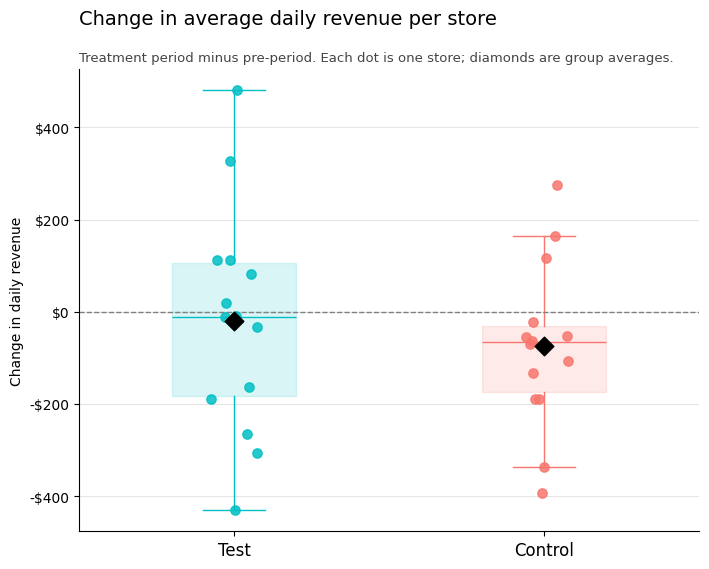

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
rng = np.random.default_rng(1)   # keeps the jitter the same every run

for i, (values, color) in enumerate([(test, "#00BFC4"), (control, "#F8766D")]):
    ax.boxplot(values, positions=[i], widths=0.4, showfliers=False, patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.15, edgecolor=color),
               whiskerprops=dict(color=color), capprops=dict(color=color),
               medianprops=dict(color=color))
    ax.scatter(i + rng.uniform(-0.08, 0.08, len(values)), values,
               color=color, s=45, alpha=0.85, zorder=3)                        # each store
    ax.scatter(i, values.mean(), marker="D", color="black", s=90, zorder=4)     # group average

ax.axhline(0, linestyle="--", color="grey", linewidth=1)
ax.set_xticks([0, 1], ["Test", "Control"], fontsize=12)
ax.yaxis.set_major_formatter(lambda y, _: f"-${abs(y):,.0f}" if y < 0 else f"${y:,.0f}")
ax.set_ylabel("Change in daily revenue")
fig.suptitle("Change in average daily revenue per store", x=0.125, ha="left", fontsize=14)
ax.set_title("Treatment period minus pre-period. Each dot is one store; diamonds are group averages.",
             loc="left", fontsize=9.5, color="#444444")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", color="#e5e5e5")
ax.set_axisbelow(True)
plt.show()

On average, the stores in the test group experienced less revenue loss than the control group during the treatment period: a gap of 55.50 dollars per store per day. But notice how spread out the stores are within each group. Some stores gained revenue, others lost hundreds of dollars a day, and the two groups overlap heavily. That spread is what the t-test weighs against the estimated lift. If every test store had dropped by about 19.50 dollars and every control store by about 75 dollars, a 55.50-dollar gap would be convincing. But when stores in the same group vary by hundreds of dollars, a 55.50-dollar difference between the group averages is easy to get by chance.

Now let's run the two-sample t-test:

In [ ]:
result = stats.ttest_ind(test, control, equal_var=True)
ci = result.confidence_interval(confidence_level=0.95)
lift = test.mean() - control.mean()

print("Two-sample t-test (test minus control)")
print(f"  Mean change, test group:    {dollars(test.mean())}")
print(f"  Mean change, control group: {dollars(control.mean())}")
print(f"  t = {result.statistic:.2f}, df = {result.df:.0f}, p-value = {result.pvalue:.2f}")
print(f"  95% confidence interval: {dollars(ci.low)} to {dollars(ci.high)}")
print(f"Lift (test minus control): +{dollars(lift)}")

Two-sample t-test (test minus control)
  Mean change, test group:    -$19.50
  Mean change, control group: -$75.00
  t = 0.68, df = 26, p-value = 0.50
  95% confidence interval: -$111.28 to $222.28
Lift (test minus control): +$55.50


Notice the final line of output shows the same estimate as PPNOC, but this time we also get a p-value: 0.50. If that number looks familiar, it's because it's the same odds as calling heads.

Using a significance level of α = 0.05, we can easily see:

**0.50 > 0.05**, so we fail to reject the null hypothesis. We don't have enough evidence to reject the hypothesis that the campaign did nothing.

Had the company actually run a t-test and gotten this p-value, they would immediately have seen that the lift was not statistically significant. In fact, even if the campaign did absolutely nothing, noise alone would produce a lift at least this large about half the time.

So yes, you could roll out the new campaign, but you might as well have flipped a coin and saved yourself four weeks.

We effectively have no meaningful evidence that the campaign worked, but we don't have evidence that it failed either. This test simply wasn't capable of telling the difference. It's possible that a real effect was hiding somewhere in the noise. However, readers with analytics experience will have already spotted another problem with the test design: insufficient statistical power.

## Section 5: Doomed from the Start

In the meeting, I asked about statistical power, and in Section 1, I promised to show you whether this test was ever big enough. First, recall what a Type I error is: a false positive. We set α to cap the probability of a false positive that we're willing to accept.

Well, there's another error a test can produce: a false negative, or **Type II error**.

> "A Type II error is when we conclude that there is no significant difference when there really is one." (Kohavi, Tang & Xu, 2020, p. 189)

Like with a Type I error, we set a threshold for the probability of a Type II error we're willing to accept. This threshold is called beta (β), and the industry convention is β = 0.20. Like α = 0.05, β = 0.20 is just a convention, not a magic number. At this level, if the campaign really does have an effect of the size we care about, we're willing to accept a 20% chance that the test misses it.

Once we've set β, we have our target **statistical power**:

$$\text{Power} = 1 - \beta$$

So with β = 0.20, power = 0.80. In other words, if the effect we care about is real, the test should detect it 80% of the time.

But 80% power to detect *what*, exactly? Power depends on how big the effect is: a large lift is easy to spot, while a small one is easy to miss. That brings us to the **minimum detectable effect (MDE)**: the smallest effect a test can reliably detect (typically with 80% power), given its sample size, how noisy the data are, and α. To see how the MDE, sample size, and noise fit together, let's define a few variables:

- **δ:** the campaign's true effect (unknown).
- **δ<sub>min</sub>:** the smallest lift the company would need to justify implementing the new ad campaign (i.e., the lift that's practically significant). When planning a test, we want its MDE to be at or below δ<sub>min</sub>.
- **σ²:** the variance of store-level changes in revenue: how much the change from one period to the next typically varies from store to store. Ideally, it's estimated from data available before the test, such as the change between two four-week windows before the campaign started, using all the stores eligible for the test.
- **n:** the number of stores in each group.

With all the pieces in place, we can estimate the sample size a test needs using van Belle's rule of thumb (van Belle, 2008), assuming equally sized groups, α = 0.05, and 80% power:

$$n \approx \frac{16\sigma^2}{\delta_{\text{min}}^2}$$

If you're planning a test, you can estimate σ² from your historical data, decide on δ<sub>min</sub>, and calculate how many stores you need in each group.

Since this wasn't done before the test, let's reverse engineer the MDE this test was actually capable of detecting with 14 stores per group, assuming α = 0.05, β = 0.20, and a store-to-store standard deviation of &#36;196.61 in revenue PSPD (estimated from the 28 stores' data before the test; see the code below). Rearranging van Belle's rule:

$$\text{MDE} \approx \frac{4\sigma}{\sqrt{n}} = \frac{4 \times \$196.61}{\sqrt{14}} \approx \$210 \text{ PSPD}$$

The exact calculation below gives &#36;216.28:

In [ ]:
# Estimate sigma using only data from before the test: each store's "placebo" change
# between two 4-week windows (history -> pre-period), when no campaign was running
placebo = store_change(daily, "history", "pre")
sigma = np.sqrt(placebo.groupby("group")["change"].var().mean())   # pooled across both groups

def power(n, effect, sd, alpha=0.05):
    """Power of a two-sided, two-sample t-test with n stores per group.
    (Like R's power.t.test, this ignores the negligible chance of a
    significant result in the wrong direction.)"""
    df = 2 * n - 2
    ncp = effect / (sd * np.sqrt(2 / n))       # noncentrality parameter
    t_crit = stats.t.ppf(1 - alpha / 2, df)
    return stats.nct.sf(t_crit, df, ncp)

mde = brentq(lambda effect: power(14, effect, sigma) - 0.80, 1, 1000)
power_at_lift = power(14, lift, sigma)
n_needed = brentq(lambda n: power(n, lift, sigma) - 0.80, 2, 1000)

print(f"Store-to-store SD of changes (sigma), pre-test data: {dollars(sigma)}")
print(f"MDE with 14 stores per group (alpha = 0.05, 80% power): {dollars(mde)} per store per day")
print(f"Power to detect a {dollars(lift)} lift with 14 stores per group: {power_at_lift:.0%}")
print(f"Stores per group needed to detect {dollars(lift)} with 80% power: {int(np.ceil(n_needed))}")

Store-to-store SD of changes (sigma), pre-test data: $196.61
MDE with 14 stores per group (alpha = 0.05, 80% power): $216.28 per store per day
Power to detect a $55.50 lift with 14 stores per group: 11%
Stores per group needed to detect $55.50 with 80% power: 198


Relative to the test group's pre-period average of &#36;1,500 per day, that means this test could only reliably detect a lift of about 14% or more (α = 0.05, 80% power). In fact, it had only about an 11% chance of detecting a true lift of &#36;55.50.

To detect a lift of &#36;55.50 PSPD with 80% power, the test would have needed roughly 200 stores per group, about 400 stores in total, instead of 28.

The reality is that this test was never capable of answering the question it was designed to answer. Even with PPNOC's positive estimate, the test was underpowered and the result was not statistically significant. The p-value tells us that the result was inconclusive, and the power tells us it was always going to be inconclusive.

The key lesson here is to perform this calculation *before* launching a test.

In summary, I'd like to highlight a few points:

**1. 28 stores (14 test, 14 control) were chosen for this experiment. Far too few.**

Store revenue is noisy, and everyday factors easily move sales by more than the 1.7% lift the test estimated. Picking out a signal that subtle takes far more stores (roughly 200 per group, as we just saw).

**2. The analysis window was 8 weeks (a 4-week pre-period and a 4-week treatment period). A longer test won't save a test this underpowered.**

Eight weeks of daily data might seem like plenty, but there's a catch. A store that does well on a given day tends to do well on most days, so measuring the same store over and over tells us less than it seems, a bit like asking the same person the same survey question 56 times and counting it as 56 responses. Statisticians call this *within-cluster correlation*. So instead of 1,568 independent observations (28 stores × 8 weeks × 7 days), we effectively have something much closer to 28.

**3. Stores should be randomly selected and randomly assigned. Without random assignment, even a proper analysis can give a biased result.**

The stores weren't randomly selected, so the results may not generalize to the rest of the company. They weren't randomly assigned either, so the two groups may not have been comparable from the start. In fact, there's a warning sign: in the pre-period, the test group averaged &#36;1,500 per day and the control group &#36;2,500. Stores this different may have been on different growth trends all along, so some or all of the "lift" could simply be those trends continuing.

**4. In the meeting, no one mentioned the lift the company actually needed to see.**

Even if the +1.7% lift were real, would it cover the cost of the campaign? That's a question for the business, not the test: the difference between statistical significance (is the effect real?) and practical significance (is it big enough to matter?). Ideally, the company would have worked out its break-even lift before the test and made sure the test could detect it. Instead, the only thing that mattered was the one number PPNOC produced. If it was positive, success. If it was negative, probably something wrong with the data. (No joke, that's actually how things worked.)

## Conclusion

All of this is one big example of how not to run your tests.

So who's the bad guy here? Is PPNOC to blame for all of this? Not exactly. The real problem is making decisions without any measure of how much to trust the results. But homegrown methods like PPNOC make that problem far too easy to ignore, which is why I'd argue companies should shelve them in favor of established methods.

To drive the point home, suppose I work for a company, and after structuring my data a certain way, I "discover" a convenient way of predicting outcomes. The formula?

$$Y = a_0 + a_1 x_1 + \dots + a_n x_n + \text{error}$$

Without realizing it, I've just recreated a basic linear regression model. With every new hire I train, I insist they use my method, "Dan's Predictor Formula," or DPF (pretty fancy, no?). DPF soon becomes the standard for predicting everything at the company. But there's a problem. What happens when the model fails? And when it does, how do you figure out why? Googling DPF yields no results. There's no body of knowledge about it. By requiring everyone to use it, I've cut them off from an entire world of resources.

So what's the alternative? Making sure everyone in your company gets statistics training? Impractical. Hiring a stats person like me and trusting everything they say implicitly? (I wish!)

For the non-technical folks in leadership reading this post, I'd recommend adopting testing tools and processes that your stats people have vetted for the kinds of tests you actually run. Good tools make steps like calculating sample size the default rather than an afterthought. Any solution that depends on everyone being fluent in statistics is, sadly, not much of a solution.

But if I could give you one piece of advice that applies to everyone in situations like the one I experienced, it's to ask lots of questions and never take results at face value. Ask how the groups were chosen. Ask what lift the company would need to see to cover the implementation costs, and whether the test was large enough to detect it. Ask about the underlying data. And at the very least, make sure you get a p-value when the results come back.

What you really want to know is whether the test can be trusted. And if the room goes quiet when you ask what the p-value was, that's your answer.

---

### Data and Code

All numbers in this post come from a synthetic data set of 28 stores (14 test, 14 control) with 12 weeks of daily revenue: a 4-week history window, the 4-week pre-period, and the 4-week treatment period. The store-level variation was chosen for illustration. With real data, the p-value could be higher or lower, which is exactly why you need to calculate it.

- **Data set:** [synthetic_daily_12wk.csv](https://github.com/dforsberg1/how-not-to-test/raw/main/synthetic_daily_12wk.csv)
- **This notebook:** [how_not_to_test_v1.1.ipynb](https://github.com/dforsberg1/how-not-to-test/raw/main/how_not_to_test_v1.1.ipynb)

To run the code yourself, you'll need Python 3 with `numpy`, `pandas`, `scipy` (version 1.11 or later), and `matplotlib`.

### Notes

<a id="note-1"></a>**1.** This setup is called a two-sided test. Written with symbols, where δ (the Greek letter delta, commonly used to represent a difference or change) is the campaign's true effect, the hypotheses are H₀: δ = 0 and H₁: δ ≠ 0. One-sided tests also exist (e.g., H₀: δ ≤ 0 and H₁: δ > 0), but they only look for an effect in one direction. Since the ad campaign could just as easily have hurt store revenue, a two-sided test is the better choice here, because it can detect an effect in either direction.

<a id="note-2"></a>**2.** In practice, many business A/B tests use a less strict threshold, such as α = 0.10, accepting a higher risk of false positives in exchange for faster decisions.

### References

- Casella, G., & Berger, R. L. (2002). *Statistical Inference* (2nd ed.). Duxbury.
- Diez, D. M., Çetinkaya-Rundel, M., & Barr, C. D. *OpenIntro Statistics*. [LibreTexts edition](https://stats.libretexts.org/Bookshelves/Introductory_Statistics/OpenIntro_Statistics_(Diez_et_al)./04:_Foundations_for_Inference/4.04:_Hypothesis_Testing).
- Kohavi, R., Tang, D., & Xu, Y. (2020). *Trustworthy Online Controlled Experiments: A Practical Guide to A/B Testing*. Cambridge University Press.
- van Belle, G. (2008). *Statistical Rules of Thumb* (2nd ed.). Wiley.
- Wasserstein, R. L., Schirm, A. L., & Lazar, N. A. (2019). Moving to a world beyond "p < 0.05." *The American Statistician*, 73(sup1), 1–19.